In [24]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.preprocessing import LabelEncoder

In [25]:
original_dataset_path = "ecg dataset 4 classes"
cropped_dir = "cropped_ecg"
os.makedirs(
    cropped_dir,
    exist_ok=True
)
data = []

import os
print(os.listdir(original_dataset_path))

def crop_ecg_region(img):

    h, w = img.shape[:2]
    cropped = img[ int(0.20*h):int(0.96*h),
                   int(0.04*w):int(0.98*w)]
                                     
    return cropped

['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'Normal Person ECG Images (284x12=3408)']


In [26]:
import os

fold_root = "5FoldDataset"

all_images = []

for fold in os.listdir(fold_root):

    fold_path = os.path.join(
        fold_root,
        fold
    )

    for cls in os.listdir(fold_path):

        class_path = os.path.join(
            fold_path,
            cls
        )

        for img in os.listdir(class_path):

            all_images.append(
                f"{cls}/{img}"
            )

print(
    "Total Images:",
    len(all_images)
)

print(
    "Unique Images:",
    len(set(all_images))
)

Total Images: 928
Unique Images: 928


In [27]:
import os

fold_root = "5FoldDataset"

for fold in sorted(os.listdir(fold_root)):

    print(f"\n{fold}")

    total = 0

    fold_path = os.path.join(
        fold_root,
        fold
    )

    for cls in sorted(os.listdir(fold_path)):

        class_path = os.path.join(
            fold_path,
            cls
        )

        count = len(
            os.listdir(class_path)
        )

        total += count

        print(
            f"{cls}: {count}"
        )

    print(
        f"Total Images: {total}"
    )


Fold1
ECG Images of Myocardial Infarction Patients (240x12=2880): 48
ECG Images of Patient that have History of MI (172x12=2064): 35
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 47
Normal Person ECG Images (284x12=3408): 57
Total Images: 187

Fold2
ECG Images of Myocardial Infarction Patients (240x12=2880): 48
ECG Images of Patient that have History of MI (172x12=2064): 35
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 47
Normal Person ECG Images (284x12=3408): 57
Total Images: 187

Fold3
ECG Images of Myocardial Infarction Patients (240x12=2880): 48
ECG Images of Patient that have History of MI (172x12=2064): 34
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 47
Normal Person ECG Images (284x12=3408): 57
Total Images: 186

Fold4
ECG Images of Myocardial Infarction Patients (240x12=2880): 48
ECG Images of Patient that have History of MI (172x12=2064): 34
ECG Images of Patient that have abnormal heartbeat (233x12=2796): 46
Norma

In [28]:
from tqdm import tqdm
import os

data = []

for label in os.listdir(cropped_dir):

    class_folder = os.path.join(
        cropped_dir,
        label
    )

    if not os.path.isdir(class_folder):
        continue

    print(f"\nCollecting: {label}")

    for img_name in tqdm(
        os.listdir(class_folder),
        desc=label
    ):

        img_path = os.path.join(
            class_folder,
            img_name
        )

        data.append(
            [
                img_path,
                label
            ]
        )

print("Data Collection Complete")


Collecting: ECG Images of Myocardial Infarction Patients (240x12=2880)


ECG Images of Myocardial Infarction Patients (240x12=2880): 100%|██████████| 239/239 [00:00<00:00, 594213.79it/s]



Collecting: ECG Images of Patient that have History of MI (172x12=2064)


ECG Images of Patient that have History of MI (172x12=2064): 100%|██████████| 172/172 [00:00<00:00, 370529.17it/s]



Collecting: ECG Images of Patient that have abnormal heartbeat (233x12=2796)


ECG Images of Patient that have abnormal heartbeat (233x12=2796): 100%|██████████| 233/233 [00:00<00:00, 255029.44it/s]



Collecting: Normal Person ECG Images (284x12=3408)


Normal Person ECG Images (284x12=3408): 100%|██████████| 284/284 [00:00<00:00, 636315.35it/s]

Data Collection Complete


In [29]:
import pandas as pd
df = pd.DataFrame(
    data,
    columns=[
        "image_path",
        "label"
    ]
)

In [30]:
!pip install scikit-learn
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['encoded_label'] = encoder.fit_transform(
    df['label']
)

In [31]:
label_mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(
            encoder.classes_
        )
    )
)

print(label_mapping)

{'ECG Images of Myocardial Infarction Patients (240x12=2880)': 0, 'ECG Images of Patient that have History of MI (172x12=2064)': 1, 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)': 2, 'Normal Person ECG Images (284x12=3408)': 3}


In [32]:
df.to_csv(
    "ecg_dataset.csv",
    index=False
)

print(
    "CSV Saved Successfully"
)

CSV Saved Successfully


In [33]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device: cuda
Tesla T4


In [34]:
import torch
import torch.nn as nn

from torchvision import transforms
from torchvision import models

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from PIL import Image

In [35]:
IMG_SIZE = 224
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [36]:
class ECGDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.iloc[idx]['image_path']

        label = self.df.iloc[idx]['encoded_label']

        image = Image.open(
            img_path
        ).convert('RGB')

        if self.transform:

            image = self.transform(image)

        return image, label

In [37]:
%pip install seaborn
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [38]:
NUM_CLASSES = 4

models_dict = {
    "ResNet50": models.resnet50(weights="DEFAULT"),
    "DenseNet169": models.densenet169(weights="DEFAULT"),
    "VGG16": models.vgg16(weights="DEFAULT"),
    "VGG19": models.vgg19(weights="DEFAULT"),
    "MobileNetV2": models.mobilenet_v2(weights="DEFAULT")
}

In [39]:
for name, model in models_dict.items():
    if "ResNet" in name:
        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )
    elif "DenseNet" in name:
        model.classifier = nn.Linear(
            model.classifier.in_features,
            NUM_CLASSES
        )
    elif "VGG" in name:
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            NUM_CLASSES
        )
    elif "MobileNet" in name:

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )

In [40]:
criterion = nn.CrossEntropyLoss()

In [41]:
def train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    epochs=100
):
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    test_losses = []
    test_accs = []
    for epoch in range(epochs):
        # TRAINING
        model.train()
        running_loss = 0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (
                predicted == labels
            ).sum().item()
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        
        # VALIDATION
        model.eval()
        val_running_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(
                    outputs,
                    labels
                )
                val_running_loss += loss.item()
                _, predicted = torch.max(
                    outputs,
                    1
                )
                val_total += labels.size(0)
                val_correct += (
                    predicted == labels
                ).sum().item()
        val_loss = (
            val_running_loss /
            len(val_loader)
        )
        val_acc = (
            100 *
            val_correct /
            val_total
        )
        
        test_running_loss = 0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
        
            for images, labels in test_loader:
        
                images = images.to(device)
                labels = labels.to(device)
        
                outputs = model(images)
        
                loss = criterion(
                    outputs,
                    labels
                )
        
                test_running_loss += loss.item()
        
                _, predicted = torch.max(
                    outputs,
                    1
                )
        
                test_total += labels.size(0)
        
                test_correct += (
                    predicted == labels
                ).sum().item()
        
        test_loss = (
            test_running_loss /
            len(test_loader)
        )
        
        test_acc = (
            100 *
            test_correct /
            test_total
        )
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}%"
        )
    return (
            train_losses,
            train_accs,
            val_losses,
            val_accs,
            test_losses,
            test_accs
        )

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.metrics import cohen_kappa_score

def evaluate_model(
    model,
    test_loader,
    device
):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(
                outputs,
                1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )
   
    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )
    kappa = cohen_kappa_score(
        all_labels,
        all_preds
    )
    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    return (
        acc,
        precision,
        recall,
        f1,
        kappa,
        cm
    )

In [43]:
results = []
all_histories = {}
all_confusion_matrices = {}
saved_models = {}

In [44]:
import pickle
import copy
from sklearn.model_selection import train_test_split

saved_models = {}
def train_single_model(
    model_name,
    base_model
): 
    fold_results = []
    run_kappas = []
    
    print(f"\nTraining {model_name}")
    run_accuracies = []
    run_precisions = []
    run_recalls = []
    run_f1s = []

    run_cms = []

    run_train_accs = []
    run_val_accs = []

    run_train_losses = []
    run_val_losses = []

    run_test_accs = []
    run_test_losses = []
    
    #for saving all the models
    
    # best_val_acc = 0
    # best_model = None
    
    for fold in range(5):
        train_data = []
        test_data = []
        test_fold = f"Fold{fold+1}"
        print(f"\nFold {fold+1}/5")
        
        test_folder = os.path.join(
        fold_root,
        test_fold
        )
        
        for label in os.listdir(test_folder):
        
            label_folder = os.path.join(
                test_folder,
                label
            )
            if not os.path.isdir(label_folder):
               continue
            for img in os.listdir(label_folder):
        
                test_data.append(
                    [
                        os.path.join(
                            label_folder,
                            img
                        ),
                        label
                    ]
                )
        
        for other_fold in range(5):

            if other_fold == fold:
                continue
        
            train_folder = os.path.join(
                fold_root,
                f"Fold{other_fold+1}"
            )
        
            for label in os.listdir(train_folder):
        
                label_folder = os.path.join(
                    train_folder,
                    label
                )
        
                for img in os.listdir(label_folder):
        
                    train_data.append(
                        [
                            os.path.join(
                                label_folder,
                                img
                            ),
                            label
                        ]
                    )
        train_df = pd.DataFrame(
            train_data,
            columns=[
                "image_path",
                "label"
            ]
        )
        
        test_df = pd.DataFrame(
            test_data,
            columns=[
                "image_path",
                "label"
            ]
        )
        test_df.to_csv(
        f"test_df_fold{fold+1}.csv",
        index=False
        )
        print("Total images in Trainable batch", len(train_df))
        print("Total images in Test batch against trainable batch", len(test_df))
            
        train_df["encoded_label"] = encoder.transform(
        train_df["label"]
        )
        
        test_df["encoded_label"] = encoder.transform(
        test_df["label"]
        )
        
        train_df, val_df = train_test_split(
        train_df,
        test_size=0.15,
        random_state=42,
        stratify=train_df["encoded_label"]
        )
        
        train_dataset = ECGDataset(
            train_df,
            transform=train_transform
        )
        
        val_dataset = ECGDataset(
            val_df,
            transform=test_transform
        )
        
        test_dataset = ECGDataset(
            test_df,
            transform=test_transform
        )    
        train_loader = DataLoader(
            train_dataset,
            batch_size=16,
            shuffle=True
        )
        
        val_loader = DataLoader(
            val_dataset,
            batch_size=16,
            shuffle=False
        )
        
        test_loader = DataLoader(
            test_dataset,
            batch_size=16,
            shuffle=False
        )
        
        model = copy.deepcopy(
            base_model
        )

        model = model.to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=1e-4
        )

        train_losses,\
        train_accs,\
        val_losses,\
        val_accs,\
        test_losses,\
        test_accs = train_model(
            model,
            train_loader,
            val_loader,
            test_loader,
            criterion,
            optimizer,
            device,
            epochs=100
        )
        
        current_val_acc = max(val_accs)
        
        # if current_val_acc > best_val_acc:
        #     best_val_acc = current_val_acc
        #     best_model = copy.deepcopy( model)
            
        acc,\
        precision,\
        recall,\
        f1,\
        kappa,\
        cm = evaluate_model(
            model,
            test_loader,
            device
        )       
        run_kappas.append(
        kappa
        )
        fold_results.append({
            "Fold": fold+1,
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Kappa": kappa
        })
        torch.save(
        model.state_dict(),
        f"{model_name}_fold{fold+1}.pth"
        )
        
        run_accuracies.append(acc)
        run_precisions.append(precision)
        run_recalls.append(recall)
        run_f1s.append(f1)
        run_cms.append(cm)
        run_train_accs.append(train_accs)
        run_val_accs.append(val_accs)
        run_train_losses.append(train_losses)
        run_val_losses.append(val_losses)
        run_test_accs.append(test_accs)
        run_test_losses.append(test_losses)

    pd.DataFrame(
    fold_results
    ).to_csv(
        f"{model_name}_fold_results.csv",
        index=False
    )
    
    mean_cm = np.mean(
        run_cms,
        axis=0
    )

    all_confusion_matrices[model_name] = mean_cm

    all_histories[model_name] = {

    "train_acc":
    np.mean(run_train_accs,axis=0),

    "val_acc":
    np.mean(run_val_accs,axis=0),

    "test_acc":
    np.mean(run_test_accs,axis=0),

    "train_loss":
    np.mean(run_train_losses,axis=0),

    "val_loss":
    np.mean(run_val_losses,axis=0),

    "test_loss":
    np.mean(run_test_losses,axis=0)
    }

    results.append({
    "Model": model_name,

    "Accuracy Mean": np.mean(run_accuracies) * 100,
    "Accuracy Std": np.std(run_accuracies) * 100,

    "Precision Mean": np.mean(run_precisions) * 100,
    "Precision Std": np.std(run_precisions) * 100,

    "Recall Mean": np.mean(run_recalls) * 100,
    "Recall Std": np.std(run_recalls) * 100,

    "F1 Mean": np.mean(run_f1s) * 100,
    "F1 Std": np.std(run_f1s) * 100,

    "Kappa Mean": np.mean(run_kappas),
    "Kappa Std": np.std(run_kappas)
    })
    
    print(
    f"{model_name} Mean Accuracy: "
    f"{np.mean(run_accuracies)*100:.2f}%"
    )
    # saved_models[model_name] = best_model
    # print(
    # f"Best Validation Accuracy: "
    # f"{best_val_acc:.2f}%"
    # )

    # torch.save(
    # best_model.state_dict(),
    # f"{model_name}.pth"
    # )
    # torch.save(
    # best_model,
    # f"{model_name}_full.pth"
    # )
    
    with open(
        f"{model_name}_history.pkl",
        "wb"
    ) as f:
    
        pickle.dump(
            all_histories[model_name],
            f
        )
    
    with open(
        f"{model_name}_cm.pkl",
        "wb"
    ) as f:
    
        pickle.dump(
            mean_cm,
            f
        )
    
    pd.DataFrame(
        results
    ).to_csv(
        "results.csv",
        index=False
    )
    summary = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Kappa"
    ],

    "Mean":[
        np.mean(run_accuracies)*100,
        np.mean(run_precisions)*100,
        np.mean(run_recalls)*100,
        np.mean(run_f1s)*100,
        np.mean(run_kappas)
    ],

    "Std":[
        np.std(run_accuracies)*100,
        np.std(run_precisions)*100,
        np.std(run_recalls)*100,
        np.std(run_f1s)*100,
        np.std(run_kappas)
    ]
    })
    
    summary.to_csv(
        f"{model_name}_summary.csv",
        index=False
    )
    print(model_name)
    print(f"Accuracy : {np.mean(run_accuracies)*100:.2f} ± {np.std(run_accuracies)*100:.2f}")
    print(f"Precision: {np.mean(run_precisions)*100:.2f} ± {np.std(run_precisions)*100:.2f}")
    print(f"Recall   : {np.mean(run_recalls)*100:.2f} ± {np.std(run_recalls)*100:.2f}")
    print(f"F1 Score : {np.mean(run_f1s)*100:.2f} ± {np.std(run_f1s)*100:.2f}")
    print(f"Kappa    : {np.mean(run_kappas):.4f} ± {np.std(run_kappas):.4f}")
    print(f"{model_name} saved successfully.")
    return

In [45]:
print(models_dict.keys())

dict_keys(['ResNet50', 'DenseNet169', 'VGG16', 'VGG19', 'MobileNetV2'])


In [23]:
train_single_model(
    "DenseNet169",
    models_dict["DenseNet169"]
)


Training DenseNet169

Fold 1/5
Total images in Trainable batch 741
Total images in Test batch against trainable batch 187
Epoch 1/100 | Train Loss: 0.7704 | Train Acc: 70.27% | Val Loss: 0.4088 | Val Acc: 86.61% | Test Loss: 0.4472 | Test Acc: 85.03%
Epoch 2/100 | Train Loss: 0.2836 | Train Acc: 90.30% | Val Loss: 0.2263 | Val Acc: 92.86% | Test Loss: 0.1896 | Test Acc: 93.58%
Epoch 3/100 | Train Loss: 0.2092 | Train Acc: 94.12% | Val Loss: 0.1897 | Val Acc: 93.75% | Test Loss: 0.1266 | Test Acc: 95.72%
Epoch 4/100 | Train Loss: 0.1754 | Train Acc: 94.12% | Val Loss: 0.2246 | Val Acc: 93.75% | Test Loss: 0.1421 | Test Acc: 94.65%
Epoch 5/100 | Train Loss: 0.1503 | Train Acc: 95.87% | Val Loss: 0.1949 | Val Acc: 92.86% | Test Loss: 0.0782 | Test Acc: 97.86%
Epoch 6/100 | Train Loss: 0.1143 | Train Acc: 96.03% | Val Loss: 0.1150 | Val Acc: 95.54% | Test Loss: 0.0604 | Test Acc: 97.86%
Epoch 7/100 | Train Loss: 0.0510 | Train Acc: 98.89% | Val Loss: 0.2118 | Val Acc: 94.64% | Test Loss: 

In [27]:
train_single_model(
    "ResNet50",
    models_dict["ResNet50"]
)


Training ResNet50

Fold 1/5
Total images in Trainable batch 741
Total images in Test batch against trainable batch 187
Epoch 1/100 | Train Loss: 1.1734 | Train Acc: 56.76% | Val Loss: 1.2391 | Val Acc: 57.14% | Test Loss: 1.2219 | Test Acc: 57.75%
Epoch 2/100 | Train Loss: 0.6068 | Train Acc: 78.54% | Val Loss: 0.3491 | Val Acc: 87.50% | Test Loss: 0.3093 | Test Acc: 89.84%
Epoch 3/100 | Train Loss: 0.3189 | Train Acc: 89.03% | Val Loss: 0.2748 | Val Acc: 87.50% | Test Loss: 0.1819 | Test Acc: 93.58%
Epoch 4/100 | Train Loss: 0.1824 | Train Acc: 94.28% | Val Loss: 0.2619 | Val Acc: 91.07% | Test Loss: 0.1623 | Test Acc: 95.72%
Epoch 5/100 | Train Loss: 0.1965 | Train Acc: 92.85% | Val Loss: 0.2418 | Val Acc: 91.96% | Test Loss: 0.1394 | Test Acc: 96.26%
Epoch 6/100 | Train Loss: 0.1396 | Train Acc: 95.39% | Val Loss: 0.2911 | Val Acc: 91.96% | Test Loss: 0.1351 | Test Acc: 95.19%
Epoch 7/100 | Train Loss: 0.0793 | Train Acc: 97.46% | Val Loss: 0.3516 | Val Acc: 91.07% | Test Loss: 0.1

In [23]:
train_single_model(
    "VGG16",
    models_dict["VGG16"]
)


Training VGG16

Fold 1/5
Total images in Trainable batch 741
Total images in Test batch against trainable batch 187
Epoch 1/100 | Train Loss: 1.1997 | Train Acc: 43.56% | Val Loss: 0.9893 | Val Acc: 65.18% | Test Loss: 0.9423 | Test Acc: 67.38%
Epoch 2/100 | Train Loss: 0.8716 | Train Acc: 63.12% | Val Loss: 0.8366 | Val Acc: 64.29% | Test Loss: 0.7987 | Test Acc: 64.17%
Epoch 3/100 | Train Loss: 0.6833 | Train Acc: 75.20% | Val Loss: 0.4249 | Val Acc: 81.25% | Test Loss: 0.4092 | Test Acc: 82.35%
Epoch 4/100 | Train Loss: 0.3123 | Train Acc: 89.35% | Val Loss: 0.1910 | Val Acc: 94.64% | Test Loss: 0.1957 | Test Acc: 93.58%
Epoch 5/100 | Train Loss: 0.2283 | Train Acc: 92.85% | Val Loss: 0.1384 | Val Acc: 95.54% | Test Loss: 0.1230 | Test Acc: 94.65%
Epoch 6/100 | Train Loss: 0.1510 | Train Acc: 95.39% | Val Loss: 0.1588 | Val Acc: 96.43% | Test Loss: 0.2158 | Test Acc: 94.65%
Epoch 7/100 | Train Loss: 0.1914 | Train Acc: 93.96% | Val Loss: 0.1475 | Val Acc: 95.54% | Test Loss: 0.1069

In [ ]:
train_single_model(
    "VGG19",
    models_dict["VGG19"]
)


Training VGG19

Fold 1/5
Total images in Trainable batch 741
Total images in Test batch against trainable batch 187
Epoch 1/100 | Train Loss: 1.2855 | Train Acc: 39.59% | Val Loss: 1.5316 | Val Acc: 33.04% | Test Loss: 1.4455 | Test Acc: 36.90%
Epoch 4/100 | Train Loss: 0.6177 | Train Acc: 78.86% | Val Loss: 0.2418 | Val Acc: 91.07% | Test Loss: 0.2410 | Test Acc: 90.91%
Epoch 5/100 | Train Loss: 0.4088 | Train Acc: 86.33% | Val Loss: 0.4154 | Val Acc: 86.61% | Test Loss: 0.3362 | Test Acc: 88.24%
Epoch 6/100 | Train Loss: 0.2423 | Train Acc: 92.21% | Val Loss: 0.6140 | Val Acc: 82.14% | Test Loss: 0.6956 | Test Acc: 86.63%
Epoch 7/100 | Train Loss: 0.3917 | Train Acc: 88.08% | Val Loss: 0.0677 | Val Acc: 99.11% | Test Loss: 0.1196 | Test Acc: 96.26%
Epoch 8/100 | Train Loss: 0.1358 | Train Acc: 94.59% | Val Loss: 0.1081 | Val Acc: 96.43% | Test Loss: 0.1002 | Test Acc: 96.26%
Epoch 9/100 | Train Loss: 0.0702 | Train Acc: 97.62% | Val Loss: 0.1750 | Val Acc: 95.54% | Test Loss: 0.1389

In [25]:
train_single_model(
    "MobileNetV2",
    models_dict["MobileNetV2"]
)


Training MobileNetV2

Fold 1/5
Total images in Trainable batch 741
Total images in Test batch against trainable batch 187
Epoch 1/100 | Train Loss: 1.2759 | Train Acc: 45.15% | Val Loss: 1.2607 | Val Acc: 50.00% | Test Loss: 1.2246 | Test Acc: 60.43%
Epoch 2/100 | Train Loss: 1.0434 | Train Acc: 62.64% | Val Loss: 0.8861 | Val Acc: 74.11% | Test Loss: 0.8396 | Test Acc: 71.12%
Epoch 3/100 | Train Loss: 0.7657 | Train Acc: 73.13% | Val Loss: 0.6194 | Val Acc: 77.68% | Test Loss: 0.5829 | Test Acc: 82.35%
Epoch 4/100 | Train Loss: 0.5611 | Train Acc: 82.99% | Val Loss: 0.4291 | Val Acc: 86.61% | Test Loss: 0.3925 | Test Acc: 89.30%
Epoch 5/100 | Train Loss: 0.4271 | Train Acc: 86.49% | Val Loss: 0.3631 | Val Acc: 86.61% | Test Loss: 0.3613 | Test Acc: 87.70%
Epoch 6/100 | Train Loss: 0.3769 | Train Acc: 86.17% | Val Loss: 0.2585 | Val Acc: 91.07% | Test Loss: 0.2624 | Test Acc: 91.44%
Epoch 7/100 | Train Loss: 0.3234 | Train Acc: 88.71% | Val Loss: 0.1890 | Val Acc: 96.43% | Test Loss: 

In [24]:
import pickle

all_histories = {}
model_names = [
    "DenseNet169",
    "ResNet50",
    "VGG16",
    "VGG19",
    "MobileNetV2"
]

for model_name in model_names:

    with open(
        f"{model_name}_history.pkl",
        "rb"
    ) as f:

        all_histories[model_name] = pickle.load(f)

print(all_histories.keys())

dict_keys(['DenseNet169', 'ResNet50', 'VGG16', 'VGG19', 'MobileNetV2'])


In [25]:
class_names = [
    "MI",
    "H.MI",
    "AH",
    "NP"
]

In [26]:
# global_preds = np.array(global_preds)
# global_labels = np.array(global_labels)

# cm = confusion_matrix(global_labels, global_preds)

# accuracy = accuracy_score(global_labels, global_preds)

# precision = precision_score(
#     global_labels,
#     global_preds,
#     average="macro",
#     zero_division=0
# )

# recall = recall_score(
#     global_labels,
#     global_preds,
#     average="macro",
#     zero_division=0
# )

# f1 = f1_score(
#     global_labels,
#     global_preds,
#     average="macro",
#     zero_division=0
# )

# kappa = cohen_kappa_score(
#     global_labels,
#     global_preds
# )

# print(cm)
# new densenet code for the overall prediction
import copy
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

global_preds = []
global_labels = []

model_name = "DenseNet169"

for fold in range(5):

    print(f"Evaluating Fold {fold+1}")

    #############################################
    # Load Fold Test CSV
    #############################################

    test_df = pd.read_csv(
        f"test_df_fold{fold+1}.csv"
    )

    test_df["encoded_label"] = encoder.transform(
        test_df["label"]
    )

    test_dataset = ECGDataset(
        test_df,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    #############################################
    # Load Saved Model
    #############################################

    model = copy.deepcopy(
        models_dict[model_name]
    )

    model.load_state_dict(
        torch.load(
            f"{model_name}_fold{fold+1}.pth",
            map_location=device
        )
    )

    model = model.to(device)

    model.eval()

    #############################################
    # Predict Entire Fold
    #############################################

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            global_preds.extend(
                preds.cpu().numpy()
            )

            global_labels.extend(
                labels.numpy()
            )

Evaluating Fold 1
Evaluating Fold 2
Evaluating Fold 3
Evaluating Fold 4
Evaluating Fold 5


In [26]:
# cm_densenet = compute_model_confusion("DenseNet169")
global_preds = np.array(global_preds)
global_labels = np.array(global_labels)

cm = confusion_matrix(
    global_labels,
    global_preds
)

accuracy = accuracy_score(
    global_labels,
    global_preds
)

precision = precision_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

recall = recall_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

kappa = cohen_kappa_score(
    global_labels,
    global_preds
)

print(cm)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print(f"Kappa : {kappa:.4f}")

[[239   0   0   0]
 [  0 167   3   2]
 [  1   5 224   3]
 [  0   0   0 284]]
Accuracy : 98.49%
Precision : 98.41%
Recall : 98.31%
F1 Score : 98.35%
Kappa : 0.9797


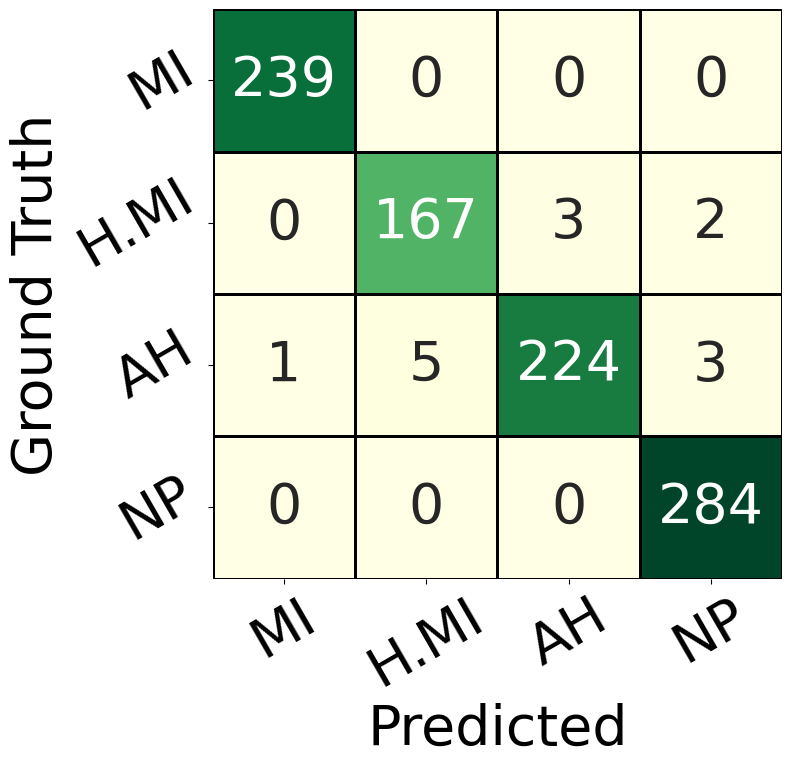

In [27]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# CLASS_NAMES = ["MI","HMI","AH","NP"]

# def plot_cm(cm,title):

#     plt.figure(figsize=(6,5))

#     sns.heatmap(
#         cm,
#         annot=True,
#         fmt=".1f",
#         cmap="Blues",
#         xticklabels=CLASS_NAMES,
#         yticklabels=CLASS_NAMES
#     )

#     plt.xlabel("Predicted")

#     plt.ylabel("True")

#     plt.title(title)

#     plt.tight_layout()

#     plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black",
    cbar=False,
    square=True,
    annot_kws={
        "size":40
    }
)

plt.xlabel(
    "Predicted",
    fontsize=40
)

plt.ylabel(
    "Ground Truth",
    fontsize=40
)

plt.xticks(
    rotation=30,
    ha="center",
    fontsize=40
)

plt.yticks(
    rotation=30,
    fontsize=40
)

plt.tight_layout()

plt.savefig(
    f"{model_name}_ConfusionMatrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [28]:
# new code for resnet confmatrix to plot all over predictions o=not just the average
import copy
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

global_preds = []
global_labels = []

model_name = "ResNet50"

for fold in range(5):

    print(f"Evaluating Fold {fold+1}")

    # Load Fold Test CSV

    test_df = pd.read_csv(
        f"test_df_fold{fold+1}.csv"
    )

    test_df["encoded_label"] = encoder.transform(
        test_df["label"]
    )

    test_dataset = ECGDataset(
        test_df,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )
    
    # Load Saved Model

    model = copy.deepcopy(
        models_dict[model_name]
    )

    model.load_state_dict(
        torch.load(
            f"{model_name}_fold{fold+1}.pth",
            map_location=device
        )
    )

    model = model.to(device)

    model.eval()

    # Predict Entire Fold

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            global_preds.extend(
                preds.cpu().numpy()
            )

            global_labels.extend(
                labels.numpy()
            )

Evaluating Fold 1
Evaluating Fold 2
Evaluating Fold 3
Evaluating Fold 4
Evaluating Fold 5


In [29]:
global_preds = np.array(global_preds)
global_labels = np.array(global_labels)

cm = confusion_matrix(
    global_labels,
    global_preds
)

accuracy = accuracy_score(
    global_labels,
    global_preds
)

precision = precision_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

recall = recall_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

kappa = cohen_kappa_score(
    global_labels,
    global_preds
)

print(cm)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print(f"Kappa : {kappa:.4f}")

[[236   3   0   0]
 [  0 165   7   0]
 [  1   6 220   6]
 [  0   0   2 282]]
Accuracy : 97.31%
Precision : 97.10%
Recall : 97.10%
F1 Score : 97.09%
Kappa : 0.9637


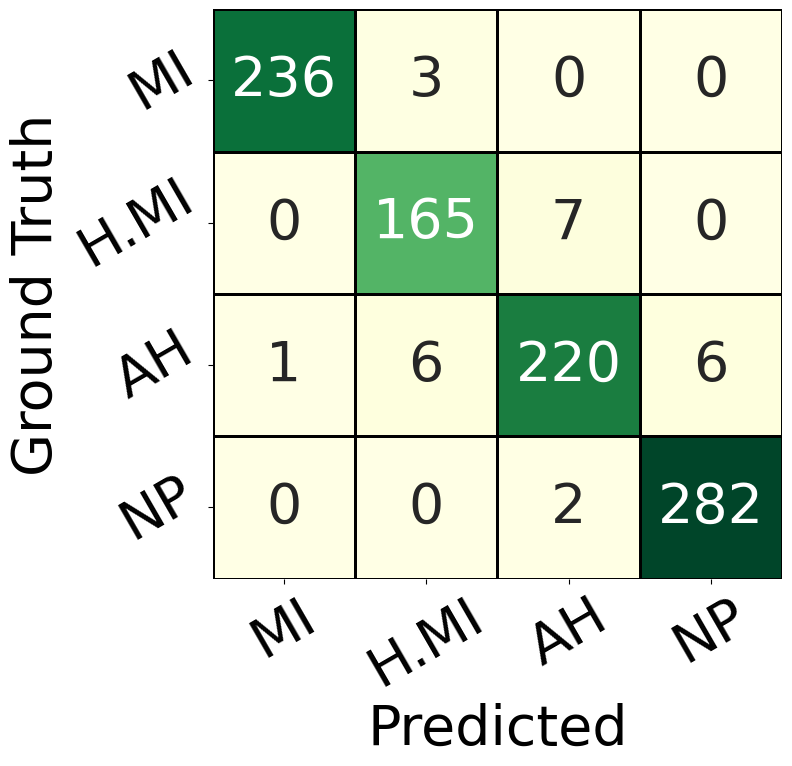

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black",
    cbar=False,
    square=True,
    annot_kws={
        "size":40
    }
)

plt.xlabel(
    "Predicted",
    fontsize=40
)

plt.ylabel(
    "Ground Truth",
    fontsize=40
)

plt.xticks(
    rotation=30,
    ha="center",
    fontsize=40
)

plt.yticks(
    rotation=30,
    fontsize=40
)

plt.tight_layout()

plt.savefig(
    f"{model_name}_ConfusionMatrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [31]:
# same for VGG16 and 19 and then for mobilenet
import copy
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

global_preds = []
global_labels = []

model_name = "VGG16"

for fold in range(5):

    print(f"Evaluating Fold {fold+1}")

    #############################################
    # Load Fold Test CSV
    #############################################

    test_df = pd.read_csv(
        f"test_df_fold{fold+1}.csv"
    )

    test_df["encoded_label"] = encoder.transform(
        test_df["label"]
    )

    test_dataset = ECGDataset(
        test_df,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    #############################################
    # Load Saved Model
    #############################################

    model = copy.deepcopy(
        models_dict[model_name]
    )

    model.load_state_dict(
        torch.load(
            f"{model_name}_fold{fold+1}.pth",
            map_location=device
        )
    )

    model = model.to(device)

    model.eval()

    #############################################
    # Predict Entire Fold
    #############################################

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            global_preds.extend(
                preds.cpu().numpy()
            )

            global_labels.extend(
                labels.numpy()
            )

Evaluating Fold 1
Evaluating Fold 2
Evaluating Fold 3
Evaluating Fold 4
Evaluating Fold 5


In [32]:
global_preds = np.array(global_preds)
global_labels = np.array(global_labels)

cm = confusion_matrix(
    global_labels,
    global_preds
)

accuracy = accuracy_score(
    global_labels,
    global_preds
)

precision = precision_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

recall = recall_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

kappa = cohen_kappa_score(
    global_labels,
    global_preds
)

print(cm)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print(f"Kappa : {kappa:.4f}")

[[239   0   0   0]
 [  2 168   1   1]
 [  6   7 213   7]
 [  0   0   0 284]]
Accuracy : 97.41%
Precision : 97.39%
Recall : 97.27%
F1 Score : 97.27%
Kappa : 0.9652


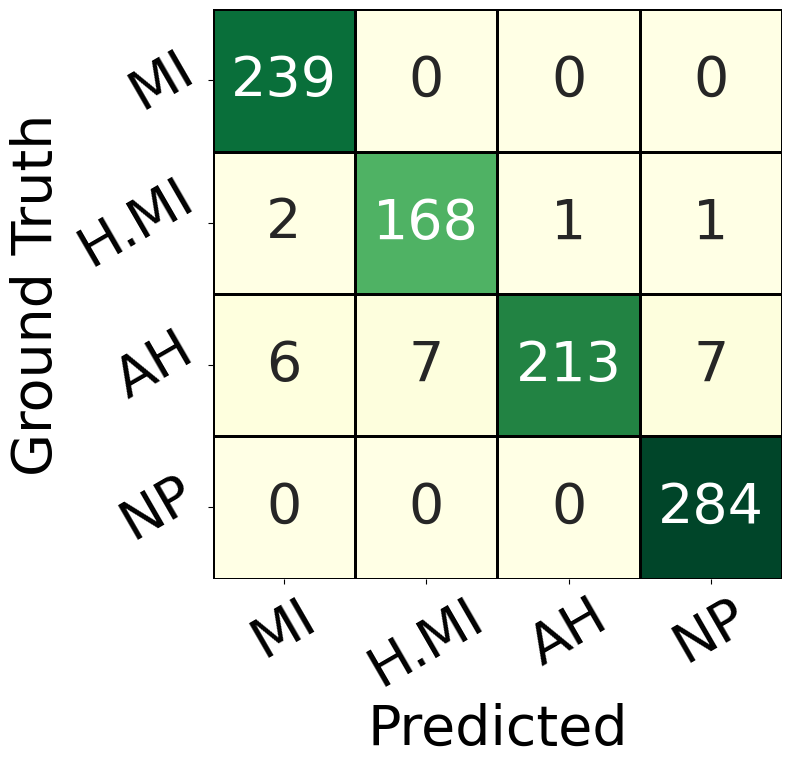

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black",
    cbar=False,
    square=True,
    annot_kws={
        "size":40
    }
)

plt.xlabel(
    "Predicted",
    fontsize=40
)

plt.ylabel(
    "Ground Truth",
    fontsize=40
)

plt.xticks(
    rotation=30,
    ha="center",
    fontsize=40
)

plt.yticks(
    rotation=30,
    fontsize=40
)

plt.tight_layout()

plt.savefig(
    f"{model_name}_ConfusionMatrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [34]:
import copy
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

global_preds = []
global_labels = []

model_name = "VGG19"

for fold in range(5):

    print(f"Evaluating Fold {fold+1}")

    #############################################
    # Load Fold Test CSV
    #############################################

    test_df = pd.read_csv(
        f"test_df_fold{fold+1}.csv"
    )

    test_df["encoded_label"] = encoder.transform(
        test_df["label"]
    )

    test_dataset = ECGDataset(
        test_df,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    #############################################
    # Load Saved Model
    #############################################

    model = copy.deepcopy(
        models_dict[model_name]
    )

    model.load_state_dict(
        torch.load(
            f"{model_name}_fold{fold+1}.pth",
            map_location=device
        )
    )

    model = model.to(device)

    model.eval()

    #############################################
    # Predict Entire Fold
    #############################################

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            global_preds.extend(
                preds.cpu().numpy()
            )

            global_labels.extend(
                labels.numpy()
            )

Evaluating Fold 1
Evaluating Fold 2
Evaluating Fold 3
Evaluating Fold 4
Evaluating Fold 5


In [35]:
global_preds = np.array(global_preds)
global_labels = np.array(global_labels)

cm = confusion_matrix(
    global_labels,
    global_preds
)

accuracy = accuracy_score(
    global_labels,
    global_preds
)

precision = precision_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

recall = recall_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

kappa = cohen_kappa_score(
    global_labels,
    global_preds
)

print(cm)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print(f"Kappa : {kappa:.4f}")

[[191   0   0  48]
 [  0 134   0  38]
 [  5   5 168  55]
 [  0   0   1 283]]
Accuracy : 83.62%
Precision : 90.00%
Recall : 82.39%
F1 Score : 84.38%
Kappa : 0.7763


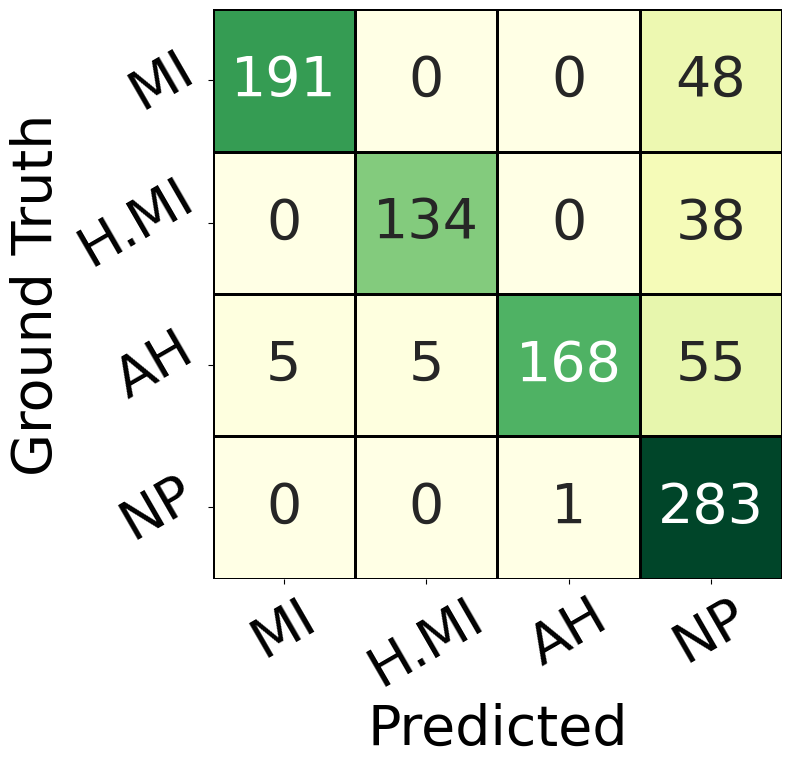

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black",
    cbar=False,
    square=True,
    annot_kws={
        "size":40
    }
)

plt.xlabel(
    "Predicted",
    fontsize=40
)

plt.ylabel(
    "Ground Truth",
    fontsize=40
)

plt.xticks(
    rotation=30,
    ha="center",
    fontsize=40
)

plt.yticks(
    rotation=30,
    fontsize=40
)

plt.tight_layout()

plt.savefig(
    f"{model_name}_ConfusionMatrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [37]:
import copy
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score
)

global_preds = []
global_labels = []

model_name = "MobileNetV2"

for fold in range(5):

    print(f"Evaluating Fold {fold+1}")

    #############################################
    # Load Fold Test CSV
    #############################################

    test_df = pd.read_csv(
        f"test_df_fold{fold+1}.csv"
    )

    test_df["encoded_label"] = encoder.transform(
        test_df["label"]
    )

    test_dataset = ECGDataset(
        test_df,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    #############################################
    # Load Saved Model
    #############################################

    model = copy.deepcopy(
        models_dict[model_name]
    )

    model.load_state_dict(
        torch.load(
            f"{model_name}_fold{fold+1}.pth",
            map_location=device
        )
    )

    model = model.to(device)

    model.eval()

    #############################################
    # Predict Entire Fold
    #############################################

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            global_preds.extend(
                preds.cpu().numpy()
            )

            global_labels.extend(
                labels.numpy()
            )

Evaluating Fold 1
Evaluating Fold 2
Evaluating Fold 3
Evaluating Fold 4
Evaluating Fold 5


In [38]:
global_preds = np.array(global_preds)
global_labels = np.array(global_labels)

cm = confusion_matrix(
    global_labels,
    global_preds
)

accuracy = accuracy_score(
    global_labels,
    global_preds
)

precision = precision_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

recall = recall_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

kappa = cohen_kappa_score(
    global_labels,
    global_preds
)

print(cm)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print(f"Kappa : {kappa:.4f}")

[[239   0   0   0]
 [  0 166   2   4]
 [  2  13 215   3]
 [  0   0   2 282]]
Accuracy : 97.20%
Precision : 96.91%
Recall : 97.02%
F1 Score : 96.93%
Kappa : 0.9623


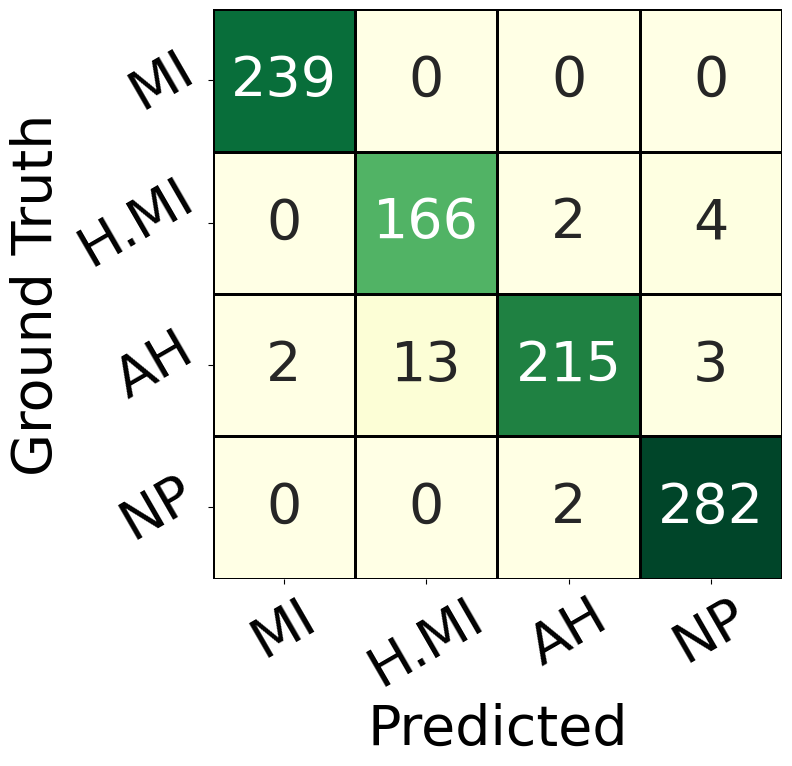

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,8)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black",
    cbar=False,
    square=True,
    annot_kws={
        "size":40
    }
)

plt.xlabel(
    "Predicted",
    fontsize=40
)

plt.ylabel(
    "Ground Truth",
    fontsize=40
)

plt.xticks(
    rotation=30,
    ha="center",
    fontsize=40
)

plt.yticks(
    rotation=30,
    fontsize=40
)

plt.tight_layout()

plt.savefig(
    f"{model_name}_ConfusionMatrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [41]:
# from collections import Counter
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     confusion_matrix,
#     cohen_kappa_score
# )

# import copy
# import pandas as pd
# import numpy as np
# import torch

# hard_fold_accs = []
# hard_fold_precisions = []
# hard_fold_recalls = []
# hard_fold_f1s = []
# hard_fold_kappas = []

# all_fold_cms = []

# global_preds = []
# global_labels = []
# for fold in range(5):

#     print(f"\nEvaluating Ensemble Fold {fold+1}")

#     # Load Fold Test Data

#     test_df = pd.read_csv(
#         f"test_df_fold{fold+1}.csv"
#     )

#     test_df["encoded_label"] = encoder.transform(
#         test_df["label"]
#     )

#     test_dataset = ECGDataset(
#         test_df,
#         transform=test_transform
#     )

#     test_loader = DataLoader(
#         test_dataset,
#         batch_size=16,
#         shuffle=False
#     )

#     # Load Fold Models

#     models_for_fold = []

#     for model_name, base_model in models_dict.items():

#         model = copy.deepcopy(
#             base_model
#         )

#         model.load_state_dict(
#             torch.load(
#                 f"{model_name}_fold{fold+1}.pth",
#                 map_location=device
#             )
#         )

#         model = model.to(device)

#         model.eval()

#         models_for_fold.append(model)

#     # Hard Voting

#     all_preds = []
#     all_labels = []

#     for images, labels in test_loader:

#         images = images.to(device)

#         batch_predictions = []

#         for model in models_for_fold:

#             with torch.no_grad():

#                 outputs = model(images)

#                 preds = torch.argmax(
#                     outputs,
#                     dim=1
#                 )

#             batch_predictions.append(
#                 preds.cpu().numpy()
#             )

#         batch_predictions = np.array(
#             batch_predictions
#         )

#         voted_preds = []

#         for i in range(
#             batch_predictions.shape[1]
#         ):

#             vote = Counter(
#                 batch_predictions[:, i]
#             ).most_common(1)[0][0]

#             voted_preds.append(vote)

#         all_preds.extend(voted_preds)
#         all_labels.extend(labels.numpy())
#         global_preds.extend(voted_preds)
#         global_labels.extend(labels.numpy())
#     # Metrics

#     acc = accuracy_score(
#         all_labels,
#         all_preds
#     )

#     precision = precision_score(
#         all_labels,
#         all_preds,
#         average="macro"
#     )

#     recall = recall_score(
#         all_labels,
#         all_preds,
#         average="macro"
#     )

#     f1 = f1_score(
#         all_labels,
#         all_preds,
#         average="macro"
#     )

#     kappa = cohen_kappa_score(
#         all_labels,
#         all_preds
#     )

#     cm = confusion_matrix(
#         all_labels,
#         all_preds
#     )

#     hard_fold_accs.append(acc)
#     hard_fold_precisions.append(precision)
#     hard_fold_recalls.append(recall)
#     hard_fold_f1s.append(f1)
#     hard_fold_kappas.append(kappa)

#     all_fold_cms.append(cm)

#     print(
#         f"Fold {fold+1} Accuracy: "
#         f"{acc*100:.2f}%"
#     )

# # # Mean Results Across 5 Folds

# # hard_mean_acc = np.mean(
# #     hard_fold_accs
# # )

# # hard_mean_precision = np.mean(
# #     hard_fold_precisions
# # )

# # hard_mean_recall = np.mean(
# #     hard_fold_recalls
# # )

# # hard_mean_f1 = np.mean(
# #     hard_fold_f1s
# # )

# # hard_mean_kappa = np.mean(
# #     hard_fold_kappas
# # )


# # hard_mean_cm = np.mean(
# #     all_fold_cms,
# #     axis=0
# # )
# hard_mean_cm = confusion_matrix(
#     global_labels,
#     global_preds
# )
# accuracy = accuracy_score(
#     global_labels,
#     global_preds
# )

# precision = precision_score(
#     all_labels,
#     all_preds,
#     average="macro",
#     zero_division=0
# )

# recall = recall_score(
#     all_labels,
#     all_preds,
#     average="macro",
#     zero_division=0
# )

# f1 = f1_score(
#     all_labels,
#     all_preds,
#     average="macro",
#     zero_division=0
# )

# kappa = cohen_kappa_score(
#     global_labels,
#     global_preds
# )
# print("\n===== HARD VOTING (5-FOLD) =====")

# print(f"Accuracy : {np.mean(hard_fold_accs)*100:.2f} ± {np.std(hard_fold_accs)*100:.2f}")

# print(f"Precision: {np.mean(hard_fold_precisions)*100:.2f} ± {np.std(hard_fold_precisions)*100:.2f}")

# print(f"Recall   : {np.mean(hard_fold_recalls)*100:.2f} ± {np.std(hard_fold_recalls)*100:.2f}")

# print(f"F1 Score : {np.mean(hard_fold_f1s)*100:.2f} ± {np.std(hard_fold_f1s)*100:.2f}")

# print(f"Kappa    : {np.mean(hard_fold_kappas):.4f} ± {np.std(hard_fold_kappas):.4f}")


#FOR THE MEAN AND STD DEVIATION TO BE ADDED IN THE TABLE
from collections import Counter
import copy
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

hard_fold_accs = []
hard_fold_precisions = []
hard_fold_recalls = []
hard_fold_f1s = []
hard_fold_kappas = []

all_fold_cms = []

for fold in range(5):

    print(f"\nEvaluating Hard Voting Fold {fold+1}")

    # -----------------------------
    # Load Fold Test Data
    # -----------------------------

    test_df = pd.read_csv(
        f"test_df_fold{fold+1}.csv"
    )

    test_df["encoded_label"] = encoder.transform(
        test_df["label"]
    )

    test_dataset = ECGDataset(
        test_df,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    # -----------------------------
    # Load Fold Models
    # -----------------------------

    models_for_fold = []

    for model_name, base_model in models_dict.items():

        model = copy.deepcopy(base_model)

        model.load_state_dict(
            torch.load(
                f"{model_name}_fold{fold+1}.pth",
                map_location=device
            )
        )

        model = model.to(device)
        model.eval()

        models_for_fold.append(model)

    # -----------------------------
    # Hard Voting Prediction
    # -----------------------------

    all_preds = []
    all_labels = []

    for images, labels in test_loader:

        images = images.to(device)

        batch_predictions = []

        for model in models_for_fold:

            with torch.no_grad():

                outputs = model(images)

                preds = torch.argmax(outputs, dim=1)

            batch_predictions.append(
                preds.cpu().numpy()
            )

        batch_predictions = np.array(batch_predictions)

        voted_preds = []

        for i in range(batch_predictions.shape[1]):

            vote = Counter(
                batch_predictions[:, i]
            ).most_common(1)[0][0]

            voted_preds.append(vote)

        all_preds.extend(voted_preds)
        all_labels.extend(labels.numpy())

    # -----------------------------
    # Fold Metrics
    # -----------------------------

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    kappa = cohen_kappa_score(
        all_labels,
        all_preds
    )

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    hard_fold_accs.append(acc)
    hard_fold_precisions.append(precision)
    hard_fold_recalls.append(recall)
    hard_fold_f1s.append(f1)
    hard_fold_kappas.append(kappa)

    all_fold_cms.append(cm)

    print(f"Fold {fold+1} Accuracy : {acc*100:.2f}%")

# ===================================================
# FINAL 5-FOLD RESULTS
# ===================================================

print("\n========== HARD VOTING ==========")

print(f"Accuracy : {np.mean(hard_fold_accs)*100:.2f} ± {np.std(hard_fold_accs)*100:.2f}")
print(f"Precision: {np.mean(hard_fold_precisions)*100:.2f} ± {np.std(hard_fold_precisions)*100:.2f}")
print(f"Recall   : {np.mean(hard_fold_recalls)*100:.2f} ± {np.std(hard_fold_recalls)*100:.2f}")
print(f"F1 Score : {np.mean(hard_fold_f1s)*100:.2f} ± {np.std(hard_fold_f1s)*100:.2f}")
print(f"Kappa    : {np.mean(hard_fold_kappas):.4f} ± {np.std(hard_fold_kappas):.4f}")

hard_results = pd.DataFrame({

    "Model":["Hard Voting"],

    "Accuracy":[f"{np.mean(hard_fold_accs)*100:.2f} ± {np.std(hard_fold_accs)*100:.2f}"],

    "Precision":[f"{np.mean(hard_fold_precisions)*100:.2f} ± {np.std(hard_fold_precisions)*100:.2f}"],

    "Recall":[f"{np.mean(hard_fold_recalls)*100:.2f} ± {np.std(hard_fold_recalls)*100:.2f}"],

    "F1 Score":[f"{np.mean(hard_fold_f1s)*100:.2f} ± {np.std(hard_fold_f1s)*100:.2f}"],

    "Kappa":[f"{np.mean(hard_fold_kappas):.4f} ± {np.std(hard_fold_kappas):.4f}"]

})

hard_results.to_csv(
    "HardVoting_5FoldResults.csv",
    index=False
)


Evaluating Hard Voting Fold 1
Fold 1 Accuracy : 99.47%

Evaluating Hard Voting Fold 2
Fold 2 Accuracy : 99.47%

Evaluating Hard Voting Fold 3
Fold 3 Accuracy : 98.39%

Evaluating Hard Voting Fold 4
Fold 4 Accuracy : 98.92%

Evaluating Hard Voting Fold 5
Fold 5 Accuracy : 97.27%

========== HARD VOTING ==========
Accuracy : 98.70 ± 0.82
Precision: 98.63 ± 0.67
Recall   : 98.63 ± 0.95
F1 Score : 98.60 ± 0.83
Kappa    : 0.9825 ± 0.0111


In [27]:
#FOR PLOTIING THE confusion matrix of hard voting
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

import copy
import pandas as pd
import numpy as np
import torch

hard_fold_accs = []
hard_fold_precisions = []
hard_fold_recalls = []
hard_fold_f1s = []
hard_fold_kappas = []

all_fold_cms = []

global_preds = []
global_labels = []
for fold in range(5):

    print(f"\nEvaluating Ensemble Fold {fold+1}")

    # Load Fold Test Data

    test_df = pd.read_csv(
        f"test_df_fold{fold+1}.csv"
    )

    test_df["encoded_label"] = encoder.transform(
        test_df["label"]
    )

    test_dataset = ECGDataset(
        test_df,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    # Load Fold Models

    models_for_fold = []

    for model_name, base_model in models_dict.items():

        model = copy.deepcopy(
            base_model
        )

        model.load_state_dict(
            torch.load(
                f"{model_name}_fold{fold+1}.pth",
                map_location=device
            )
        )

        model = model.to(device)

        model.eval()

        models_for_fold.append(model)

    # Hard Voting

    all_preds = []
    all_labels = []

    for images, labels in test_loader:

        images = images.to(device)

        batch_predictions = []

        for model in models_for_fold:

            with torch.no_grad():

                outputs = model(images)

                preds = torch.argmax(
                    outputs,
                    dim=1
                )

            batch_predictions.append(
                preds.cpu().numpy()
            )

        batch_predictions = np.array(
            batch_predictions
        )

        voted_preds = []

        for i in range(
            batch_predictions.shape[1]
        ):

            vote = Counter(
                batch_predictions[:, i]
            ).most_common(1)[0][0]

            voted_preds.append(vote)

        all_preds.extend(voted_preds)
        all_labels.extend(labels.numpy())
        global_preds.extend(voted_preds)
        global_labels.extend(labels.numpy())
    # Metrics

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro"
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro"
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    kappa = cohen_kappa_score(
        all_labels,
        all_preds
    )

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    hard_fold_accs.append(acc)
    hard_fold_precisions.append(precision)
    hard_fold_recalls.append(recall)
    hard_fold_f1s.append(f1)
    hard_fold_kappas.append(kappa)

    all_fold_cms.append(cm)

    print(
        f"Fold {fold+1} Accuracy: "
        f"{acc*100:.2f}%"
    )

# # Mean Results Across 5 Folds

# hard_mean_acc = np.mean(
#     hard_fold_accs
# )

# hard_mean_precision = np.mean(
#     hard_fold_precisions
# )

# hard_mean_recall = np.mean(
#     hard_fold_recalls
# )

# hard_mean_f1 = np.mean(
#     hard_fold_f1s
# )

# hard_mean_kappa = np.mean(
#     hard_fold_kappas
# )


# hard_mean_cm = np.mean(
#     all_fold_cms,
#     axis=0
# )
hard_mean_cm = confusion_matrix(
    global_labels,
    global_preds
)
accuracy = accuracy_score(
    global_labels,
    global_preds
)

precision = precision_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

recall = recall_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

kappa = cohen_kappa_score(
    global_labels,
    global_preds
)
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print(f"Kappa : {kappa:.4f}")


Evaluating Ensemble Fold 1
Fold 1 Accuracy: 99.47%

Evaluating Ensemble Fold 2
Fold 2 Accuracy: 99.47%

Evaluating Ensemble Fold 3
Fold 3 Accuracy: 98.39%

Evaluating Ensemble Fold 4
Fold 4 Accuracy: 98.92%

Evaluating Ensemble Fold 5
Fold 5 Accuracy: 97.27%
Accuracy : 98.71%
Precision : 98.61%
Recall : 98.64%
F1 Score : 98.61%
Kappa : 0.9826


In [29]:
hard_mean_cm

array([[239,   0,   0,   0],
       [  0, 170,   0,   2],
       [  1,   6, 223,   3],
       [  0,   0,   0, 284]])

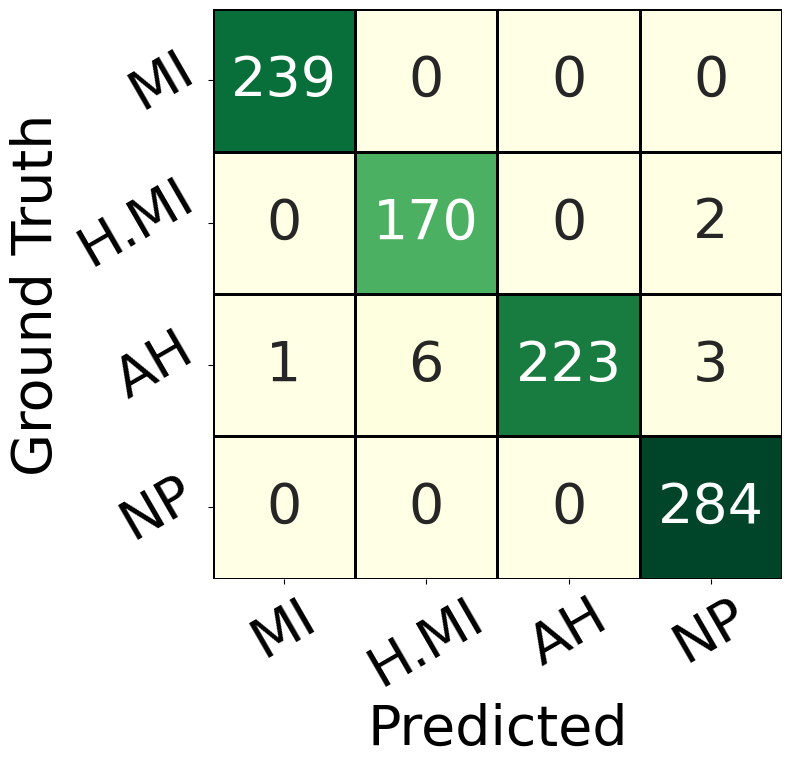

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

sns.heatmap(
    hard_mean_cm.astype(int),
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black",
    cbar=False,        
    square=True,
    annot_kws={
        "size":40
    }
)

plt.xlabel(
    "Predicted",
    fontsize=40
)

plt.ylabel(
    "Ground Truth",
    fontsize=40
)

plt.xticks(
    rotation=30,
    ha="center",
    fontsize=40
)

plt.yticks(
    rotation=30,
    fontsize=40
)

plt.tight_layout()

plt.savefig(
    "HardVoting_ConfusionMatrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [32]:
import copy
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

soft_fold_accs = []
soft_fold_precisions = []
soft_fold_recalls = []
soft_fold_f1s = []
soft_fold_kappas = []

all_fold_cms = []

for fold in range(5):

    print(f"\nEvaluating Soft Voting Fold {fold+1}")

    # -----------------------------
    # Load Fold Test Data
    # -----------------------------

    test_df = pd.read_csv(
        f"test_df_fold{fold+1}.csv"
    )

    test_df["encoded_label"] = encoder.transform(
        test_df["label"]
    )

    test_dataset = ECGDataset(
        test_df,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    # -----------------------------
    # Load Fold Models
    # -----------------------------

    models_for_fold = []

    for model_name, base_model in models_dict.items():

        model = copy.deepcopy(base_model)

        model.load_state_dict(
            torch.load(
                f"{model_name}_fold{fold+1}.pth",
                map_location=device
            )
        )

        model = model.to(device)
        model.eval()

        models_for_fold.append(model)

    # -----------------------------
    # Soft Voting Prediction
    # -----------------------------

    all_preds = []
    all_labels = []

    for images, labels in test_loader:

        images = images.to(device)

        probability_sum = None

        for model in models_for_fold:

            with torch.no_grad():

                outputs = model(images)

                probs = torch.softmax(outputs, dim=1)

            if probability_sum is None:

                probability_sum = probs

            else:

                probability_sum += probs

        probability_sum /= len(models_for_fold)

        preds = torch.argmax(
            probability_sum,
            dim=1
        ).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    # -----------------------------
    # Fold Metrics
    # -----------------------------

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    kappa = cohen_kappa_score(
        all_labels,
        all_preds
    )

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    soft_fold_accs.append(acc)
    soft_fold_precisions.append(precision)
    soft_fold_recalls.append(recall)
    soft_fold_f1s.append(f1)
    soft_fold_kappas.append(kappa)

    all_fold_cms.append(cm)

    print(f"Fold {fold+1} Accuracy : {acc*100:.2f}%")

# ===================================================
# FINAL 5-FOLD RESULTS
# ===================================================

print("\n========== SOFT VOTING ==========")

print(f"Accuracy : {np.mean(soft_fold_accs)*100:.2f} ± {np.std(soft_fold_accs)*100:.2f}")
print(f"Precision: {np.mean(soft_fold_precisions)*100:.2f} ± {np.std(soft_fold_precisions)*100:.2f}")
print(f"Recall   : {np.mean(soft_fold_recalls)*100:.2f} ± {np.std(soft_fold_recalls)*100:.2f}")
print(f"F1 Score : {np.mean(soft_fold_f1s)*100:.2f} ± {np.std(soft_fold_f1s)*100:.2f}")
print(f"Kappa    : {np.mean(soft_fold_kappas):.4f} ± {np.std(soft_fold_kappas):.4f}")

soft_results = pd.DataFrame({

    "Model":["Soft Voting"],

    "Accuracy":[f"{np.mean(soft_fold_accs)*100:.2f} ± {np.std(soft_fold_accs)*100:.2f}"],

    "Precision":[f"{np.mean(soft_fold_precisions)*100:.2f} ± {np.std(soft_fold_precisions)*100:.2f}"],

    "Recall":[f"{np.mean(soft_fold_recalls)*100:.2f} ± {np.std(soft_fold_recalls)*100:.2f}"],

    "F1 Score":[f"{np.mean(soft_fold_f1s)*100:.2f} ± {np.std(soft_fold_f1s)*100:.2f}"],

    "Kappa":[f"{np.mean(soft_fold_kappas):.4f} ± {np.std(soft_fold_kappas):.4f}"]

})

soft_results.to_csv(
    "SoftVoting_5FoldResults.csv",
    index=False
)


Evaluating Soft Voting Fold 1
Fold 1 Accuracy : 99.47%

Evaluating Soft Voting Fold 2
Fold 2 Accuracy : 99.47%

Evaluating Soft Voting Fold 3
Fold 3 Accuracy : 98.92%

Evaluating Soft Voting Fold 4
Fold 4 Accuracy : 98.92%

Evaluating Soft Voting Fold 5
Fold 5 Accuracy : 98.36%

========== SOFT VOTING ==========
Accuracy : 99.03 ± 0.41
Precision: 98.93 ± 0.34
Recall   : 99.03 ± 0.41
F1 Score : 98.96 ± 0.38
Kappa    : 0.9869 ± 0.0056


In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

import copy
import pandas as pd
import numpy as np
import torch

soft_fold_accs = []
soft_fold_precisions = []
soft_fold_recalls = []
soft_fold_f1s = []
soft_fold_kappas = []

global_preds = []
global_labels = []

for fold in range(5):

    print(f"\nEvaluating Soft Voting Fold {fold+1}")

    test_df = pd.read_csv(
        f"test_df_fold{fold+1}.csv"
    )

    test_df["encoded_label"] = encoder.transform(
        test_df["label"]
    )

    test_dataset = ECGDataset(
        test_df,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=16,
        shuffle=False
    )

    models_for_fold = []

    for model_name, base_model in models_dict.items():

        model = copy.deepcopy(base_model)

        model.load_state_dict(
            torch.load(
                f"{model_name}_fold{fold+1}.pth",
                map_location=device
            )
        )

        model = model.to(device)
        model.eval()

        models_for_fold.append(model)

    all_preds = []
    all_labels = []

    for images, labels in test_loader:

        images = images.to(device)

        batch_probabilities = []

        for model in models_for_fold:

            with torch.no_grad():

                outputs = model(images)

                probs = torch.softmax(
                    outputs,
                    dim=1
                )

            batch_probabilities.append(
                probs.cpu().numpy()
            )

        batch_probabilities = np.array(
            batch_probabilities
        )

        mean_probabilities = np.mean(
            batch_probabilities,
            axis=0
        )

        preds = np.argmax(
            mean_probabilities,
            axis=1
        )

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

        global_preds.extend(preds)
        global_labels.extend(labels.numpy())

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average="macro"
    )

    recall = recall_score(
        all_labels,
        all_preds,
        average="macro"
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    kappa = cohen_kappa_score(
        all_labels,
        all_preds
    )

    soft_fold_accs.append(acc)
    soft_fold_precisions.append(precision)
    soft_fold_recalls.append(recall)
    soft_fold_f1s.append(f1)
    soft_fold_kappas.append(kappa)

    print(f"Fold {fold+1} Accuracy : {acc*100:.2f}%")


Evaluating Soft Voting Fold 1
Fold 1 Accuracy : 99.47%

Evaluating Soft Voting Fold 2
Fold 2 Accuracy : 99.47%

Evaluating Soft Voting Fold 3
Fold 3 Accuracy : 98.92%

Evaluating Soft Voting Fold 4
Fold 4 Accuracy : 98.92%

Evaluating Soft Voting Fold 5
Fold 5 Accuracy : 98.36%


In [35]:
soft_mean_cm = confusion_matrix(
    global_labels,
    global_preds
)

accuracy = accuracy_score(
    global_labels,
    global_preds
)

precision = precision_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

recall = recall_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

kappa = cohen_kappa_score(
    global_labels,
    global_preds
)

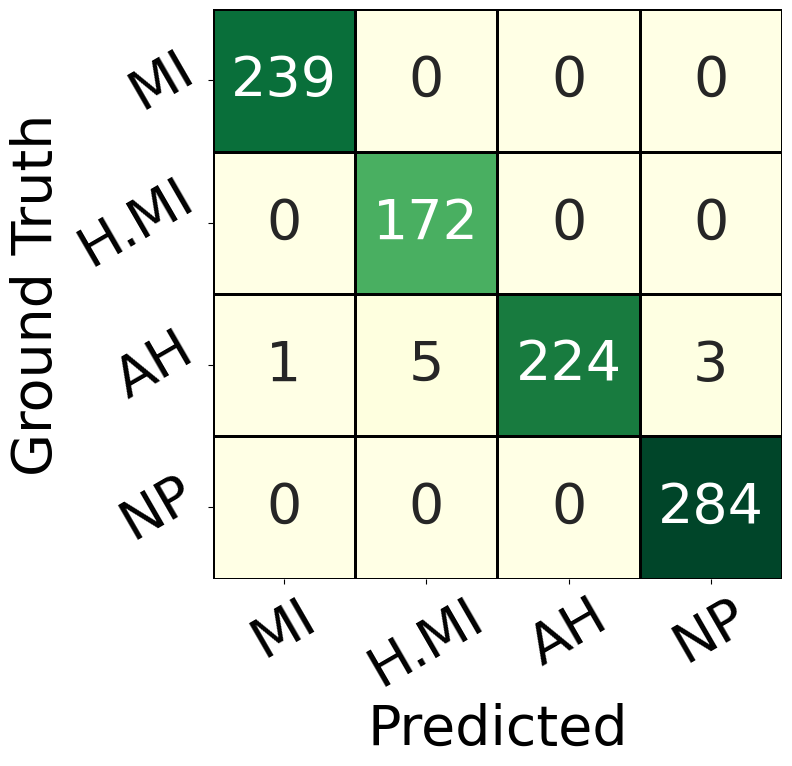

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

sns.heatmap(
    soft_mean_cm.astype(int),
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black",
    cbar=False,        
    square=True,
    annot_kws={
        "size":40
    }
)

plt.xlabel(
    "Predicted",
    fontsize=40
)

plt.ylabel(
    "Ground Truth",
    fontsize=40
)

plt.xticks(
    rotation=30,
    ha="center",
    fontsize=40
)

plt.yticks(
    rotation=30,
    fontsize=40
)

plt.tight_layout()

plt.savefig(
    "SoftVoting_ConfusionMatrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [38]:
import copy
import numpy as np
import pandas as pd
import torch

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    cohen_kappa_score
)

In [39]:
fold_features = []
fold_labels = []

for fold in range(5):

    print(f"\nProcessing Fold {fold+1}")

    test_df = pd.read_csv(
        f"test_df_fold{fold+1}.csv"
    )

    test_df["encoded_label"] = encoder.transform(
        test_df["label"]
    )

    test_dataset = ECGDataset(
        test_df,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False
    )

    fold_models = []

    for model_name, base_model in models_dict.items():

        model = copy.deepcopy(base_model)

        model.load_state_dict(
            torch.load(
                f"{model_name}_fold{fold+1}.pth",
                map_location=device
            )
        )

        model = model.to(device)

        model.eval()

        fold_models.append(model)

    current_fold_features = []
    current_fold_labels = []

    for image, label in test_loader:

        image = image.to(device)

        sample_features = []

        with torch.no_grad():

            for model in fold_models:

                output = model(image)

                probs = torch.softmax(
                    output,
                    dim=1
                )

                sample_features.extend(
                    probs.squeeze().cpu().numpy()
                )

        current_fold_features.append(sample_features)

        current_fold_labels.append(label.item())

    fold_features.append(
        np.array(current_fold_features)
    )

    fold_labels.append(
        np.array(current_fold_labels)
    )

print()

for i in range(5):

    print(
        f"Fold {i+1}:",
        fold_features[i].shape,
        fold_labels[i].shape
    )


Processing Fold 1

Processing Fold 2

Processing Fold 3

Processing Fold 4

Processing Fold 5

Fold 1: (187, 20) (187,)
Fold 2: (187, 20) (187,)
Fold 3: (186, 20) (186,)
Fold 4: (185, 20) (185,)
Fold 5: (183, 20) (183,)


In [49]:
from sklearn.linear_model import LogisticRegression

global_preds = []
global_labels = []

fold_acc = []
fold_precision = []
fold_recall = []
fold_f1 = []
fold_kappa = []

for fold in range(5):

    print(f"\nMeta Fold {fold+1}")

    X_test = fold_features[fold]
    y_test = fold_labels[fold]

    X_train = np.vstack([
        fold_features[i]
        for i in range(5)
        if i != fold
    ])

    y_train = np.hstack([
        fold_labels[i]
        for i in range(5)
        if i != fold
    ])

    meta_model = LogisticRegression(
        max_iter=1000,
        multi_class="multinomial",
        random_state=42
    )

    meta_model.fit(
        X_train,
        y_train
    )

    preds = meta_model.predict(
        X_test
    )

    global_preds.extend(preds)
    global_labels.extend(y_test)

    acc = accuracy_score(
        y_test,
        preds
    )

    prec = precision_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    rec = recall_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    kappa = cohen_kappa_score(
        y_test,
        preds
    )

    fold_acc.append(acc)
    fold_precision.append(prec)
    fold_recall.append(rec)
    fold_f1.append(f1)
    fold_kappa.append(kappa)

    print(f"Accuracy : {acc*100:.2f}%")


Meta Fold 1
Accuracy : 100.00%

Meta Fold 2
Accuracy : 99.47%

Meta Fold 3
Accuracy : 98.92%

Meta Fold 4
Accuracy : 98.92%

Meta Fold 5
Accuracy : 97.81%


In [45]:
stacking_cm = confusion_matrix(
    global_labels,
    global_preds
)

print("\n===== STACKING (5-FOLD) =====")

print(f"Accuracy : {np.mean(fold_acc)*100:.2f} ± {np.std(fold_acc)*100:.2f}")

print(f"Precision: {np.mean(fold_precision)*100:.2f} ± {np.std(fold_precision)*100:.2f}")

print(f"Recall   : {np.mean(fold_recall)*100:.2f} ± {np.std(fold_recall)*100:.2f}")

print(f"F1 Score : {np.mean(fold_f1)*100:.2f} ± {np.std(fold_f1)*100:.2f}")

print(f"Kappa    : {np.mean(fold_kappa):.4f} ± {np.std(fold_kappa):.4f}")


===== STACKING (5-FOLD) =====
Accuracy : 99.02 ± 0.73
Precision: 99.00 ± 0.64
Recall   : 98.95 ± 0.85
F1 Score : 98.96 ± 0.75
Kappa    : 0.9869 ± 0.0098


In [46]:
##########################################################
# Overall 928-image Confusion Matrix (Stacking)
##########################################################

global_preds = np.array(global_preds)
global_labels = np.array(global_labels)

stacking_cm = confusion_matrix(
    global_labels,
    global_preds
)

accuracy = accuracy_score(
    global_labels,
    global_preds
)

precision = precision_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

recall = recall_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    global_labels,
    global_preds,
    average="macro",
    zero_division=0
)

kappa = cohen_kappa_score(
    global_labels,
    global_preds
)

print(stacking_cm)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print(f"Kappa : {kappa:.4f}")

[[239   0   0   0]
 [  0 170   2   0]
 [  1   3 226   3]
 [  0   0   0 284]]
Accuracy : 99.03%
Precision : 98.98%
Recall : 98.96%
F1 Score : 98.97%
Kappa : 0.9869


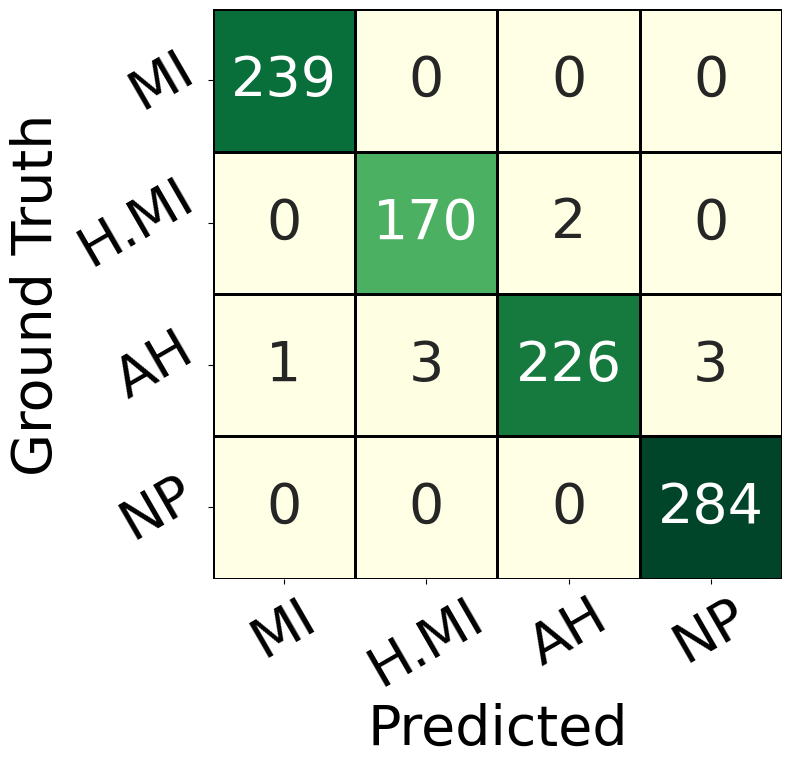

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

sns.heatmap(
    stacking_cm,
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor="black",
    cbar=False,
    square=True,
    annot_kws={
        "size":40
    }
)

plt.xlabel(
    "Predicted",
    fontsize=40
)

plt.ylabel(
    "Ground Truth",
    fontsize=40
)

plt.xticks(
    rotation=30,
    ha="center",
    fontsize=40
)

plt.yticks(
    rotation=30,
    fontsize=40
)

plt.tight_layout()

plt.savefig(
    "Stacking_ConfusionMatrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [41]:
pd.read_csv("DenseNet169_summary.csv")

,Metric,Mean,Std
0,Accuracy,98.486941,0.728655
1,Precision,98.444494,0.675560
2,Recall,98.305988,0.849204
3,F1,98.350456,0.771302
4,Kappa,0.979612,0.009836


In [42]:
pd.read_csv("DenseNet169_fold_results.csv").head()

,Fold,Accuracy,Precision,Recall,F1,Kappa
0,1,0.983957,0.982230,0.980395,0.981236,0.978398
1,2,0.989305,0.987538,0.987538,0.987538,0.985605
2,3,0.994624,0.995690,0.994681,0.995138,0.992754
3,4,0.983784,0.981009,0.983696,0.981853,0.978169
4,5,0.972678,0.975758,0.968990,0.971758,0.963135


In [43]:
import pandas as pd
import numpy as np

summary_files = {
    "DenseNet169": "DenseNet169_summary.csv",
    "ResNet50": "ResNet50_summary.csv",
    "VGG16": "VGG16_summary.csv",
    "VGG19": "VGG19_summary.csv",
    "MobileNetV2": "MobileNetV2_summary.csv",
}

rows = []

for model_name, csv_file in summary_files.items():

    df = pd.read_csv(csv_file)

    row = {"Model": model_name}

    for _, r in df.iterrows():
        metric = r["Metric"]

        row[metric] = r["Mean"]
        row[f"{metric}_std"] = r["Std"]

    rows.append(row)

In [44]:
rows.append({

    "Model":"Hard Voting",

    "Accuracy":np.mean(hard_fold_accs),
    "Accuracy_std":np.std(hard_fold_accs),

    "Precision":np.mean(hard_fold_precisions),
    "Precision_std":np.std(hard_fold_precisions),

    "Recall":np.mean(hard_fold_recalls),
    "Recall_std":np.std(hard_fold_recalls),

    "F1":np.mean(hard_fold_f1s),
    "F1_std":np.std(hard_fold_f1s),

    "Kappa":np.mean(hard_fold_kappas),
    "Kappa_std":np.std(hard_fold_kappas)
})

In [45]:
rows.append({

    "Model":"Soft Voting",

    "Accuracy":np.mean(soft_fold_accs),
    "Accuracy_std":np.std(soft_fold_accs),

    "Precision":np.mean(soft_fold_precisions),
    "Precision_std":np.std(soft_fold_precisions),

    "Recall":np.mean(soft_fold_recalls),
    "Recall_std":np.std(soft_fold_recalls),

    "F1":np.mean(soft_fold_f1s),
    "F1_std":np.std(soft_fold_f1s),

    "Kappa":np.mean(soft_fold_kappas),
    "Kappa_std":np.std(soft_fold_kappas)
})

In [47]:
rows.append({

    "Model":"Stacking (LR)",

    "Accuracy":np.mean(fold_acc),
    "Accuracy_std":np.std(fold_acc),

    "Precision":np.mean(fold_precision),
    "Precision_std":np.std(fold_precision),

    "Recall":np.mean(fold_recall),
    "Recall_std":np.std(fold_recall),

    "F1":np.mean(fold_f1),
    "F1_std":np.std(fold_f1),

    "Kappa":np.mean(fold_kappa),
    "Kappa_std":np.std(fold_kappa)

})

In [48]:
final_results = pd.DataFrame(rows)

display(final_results)

final_results.to_csv(
    "Final_All_Model_Results.csv",
    index=False
)

,Model,Accuracy,Accuracy_std,Precision,Precision_std,Recall,Recall_std,F1,F1_std,Kappa,Kappa_std
0,DenseNet169,98.486941,0.728655,98.444494,0.675560,98.305988,0.849204,98.350456,0.771302,0.979612,0.009836
1,ResNet50,97.301259,1.712296,97.178143,1.951525,97.093775,1.745975,97.091031,1.884291,0.963664,0.023037
2,VGG16,97.398803,1.937033,97.447698,1.834609,97.251728,2.092705,97.224407,2.092454,0.964938,0.026115
3,VGG19,83.650463,26.576984,79.241205,35.828227,82.405144,28.789890,79.791905,34.094256,0.766556,0.384217
4,MobileNetV2,97.192474,1.347509,97.008956,1.369555,97.011126,1.548483,96.924595,1.488035,0.962192,0.018168
5,Hard Voting,0.987009,0.008208,0.986285,0.006705,0.986305,0.009521,0.986005,0.008269,0.982494,0.011080
6,Soft Voting,0.990270,0.004124,0.989330,0.003370,0.990310,0.004105,0.989631,0.003849,0.986897,0.005558
7,Stacking (LR),0.990246,0.007255,0.989973,0.006427,0.989520,0.008538,0.989594,0.007521,0.986855,0.009787


In [49]:
paper_table = final_results.copy()

# Metrics expressed as percentages
percent_metrics = ["Accuracy", "Precision", "Recall", "F1"]

for metric in percent_metrics:

    paper_table[metric] = paper_table.apply(
        lambda x: f"{x[metric]*100:.2f} ± {x[metric+'_std']*100:.2f}"
        if x[metric] <= 1 else
        f"{x[metric]:.2f} ± {x[metric+'_std']:.2f}",
        axis=1
    )

# Kappa stays between 0 and 1
paper_table["Kappa"] = paper_table.apply(
    lambda x: f"{x['Kappa']:.4f} ± {x['Kappa_std']:.4f}",
    axis=1
)

paper_table = paper_table[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "Kappa"
    ]
]

display(paper_table)

paper_table.to_csv(
    "IEEE_Final_Table.csv",
    index=False
)

,Model,Accuracy,Precision,Recall,F1,Kappa
0,DenseNet169,98.49 ± 0.73,98.44 ± 0.68,98.31 ± 0.85,98.35 ± 0.77,0.9796 ± 0.0098
1,ResNet50,97.30 ± 1.71,97.18 ± 1.95,97.09 ± 1.75,97.09 ± 1.88,0.9637 ± 0.0230
2,VGG16,97.40 ± 1.94,97.45 ± 1.83,97.25 ± 2.09,97.22 ± 2.09,0.9649 ± 0.0261
3,VGG19,83.65 ± 26.58,79.24 ± 35.83,82.41 ± 28.79,79.79 ± 34.09,0.7666 ± 0.3842
4,MobileNetV2,97.19 ± 1.35,97.01 ± 1.37,97.01 ± 1.55,96.92 ± 1.49,0.9622 ± 0.0182
5,Hard Voting,98.70 ± 0.82,98.63 ± 0.67,98.63 ± 0.95,98.60 ± 0.83,0.9825 ± 0.0111
6,Soft Voting,99.03 ± 0.41,98.93 ± 0.34,99.03 ± 0.41,98.96 ± 0.38,0.9869 ± 0.0056
7,Stacking (LR),99.02 ± 0.73,99.00 ± 0.64,98.95 ± 0.85,98.96 ± 0.75,0.9869 ± 0.0098


In [50]:
import pickle

all_histories = {}

model_names = [
    "DenseNet169",
    "ResNet50",
    "VGG16",
    "VGG19",
    "MobileNetV2"
]

for model_name in model_names:

    with open(
        f"{model_name}_history.pkl",
        "rb"
    ) as f:

        all_histories[model_name] = pickle.load(f)

In [51]:
ensemble_train_acc = np.mean(
    [
        all_histories[m]["train_acc"]
        for m in model_names
    ],
    axis=0
)

ensemble_val_acc = np.mean(
    [
        all_histories[m]["val_acc"]
        for m in model_names
    ],
    axis=0
)

ensemble_test_acc = np.mean(
    [
        all_histories[m]["test_acc"]
        for m in model_names
    ],
    axis=0
)

In [52]:
ensemble_train_loss = np.mean(
    [
        all_histories[m]["train_loss"]
        for m in model_names
    ],
    axis=0
)

ensemble_val_loss = np.mean(
    [
        all_histories[m]["val_loss"]
        for m in model_names
    ],
    axis=0
)

ensemble_test_loss = np.mean(
    [
        all_histories[m]["test_loss"]
        for m in model_names
    ],
    axis=0
)

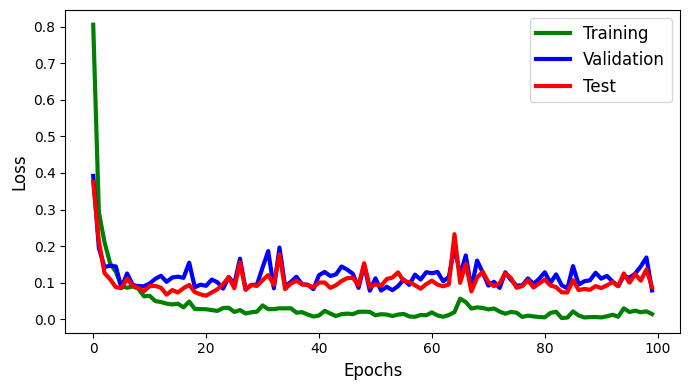

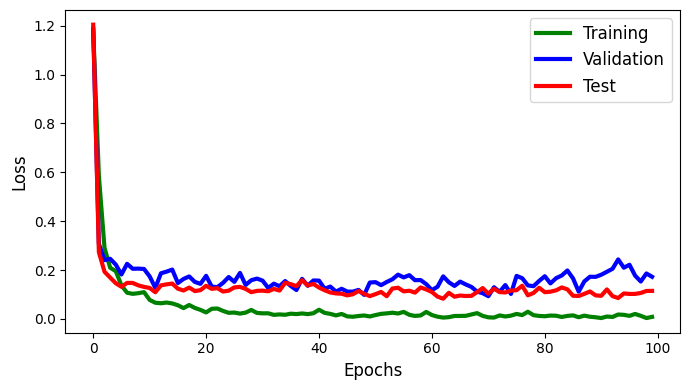

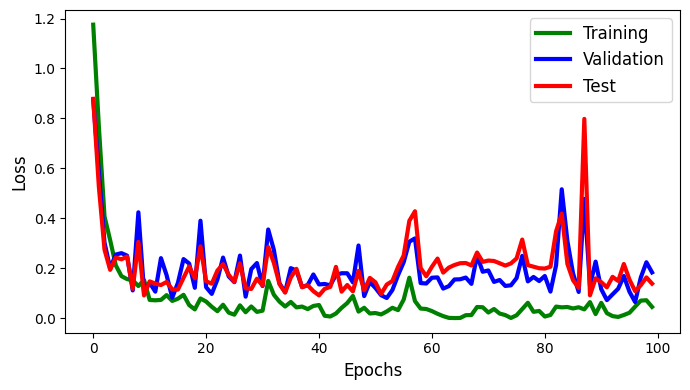

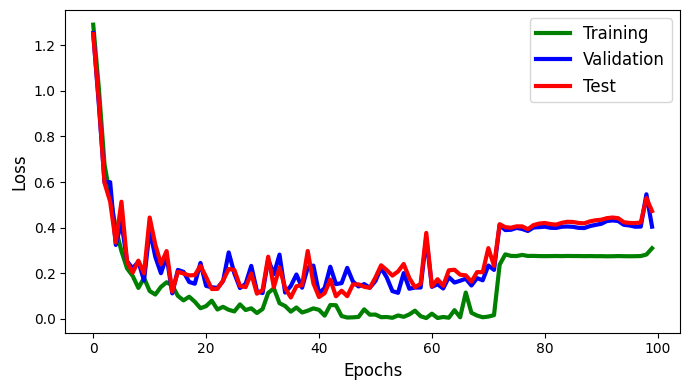

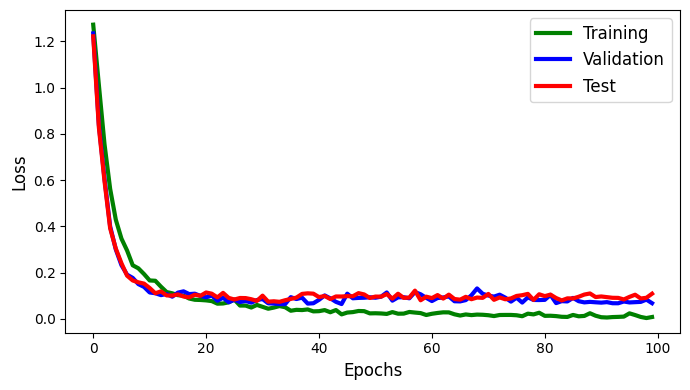

In [55]:
for model_name in model_names:

    plt.figure(figsize=(7,4))

    plt.plot(
        all_histories[model_name]["train_loss"],
        color="green",
        linewidth=3,
        label="Training"
    )

    plt.plot(
        all_histories[model_name]["val_loss"],
        color="blue",
        linewidth=3,
        label="Validation"
    )
    plt.plot(
        all_histories[model_name]["test_loss"],
        color="red",
        linewidth=3,
        label="Test"
    )
    plt.xlabel(
        "Epochs",
        fontsize=12
    )

    plt.ylabel(
        "Loss",
        fontsize=12
    )

    plt.legend(
        fontsize=12
    )

    plt.tight_layout()

    plt.savefig(
        f"{model_name}_LossCurve.png",
        dpi=600
    )

    plt.show()

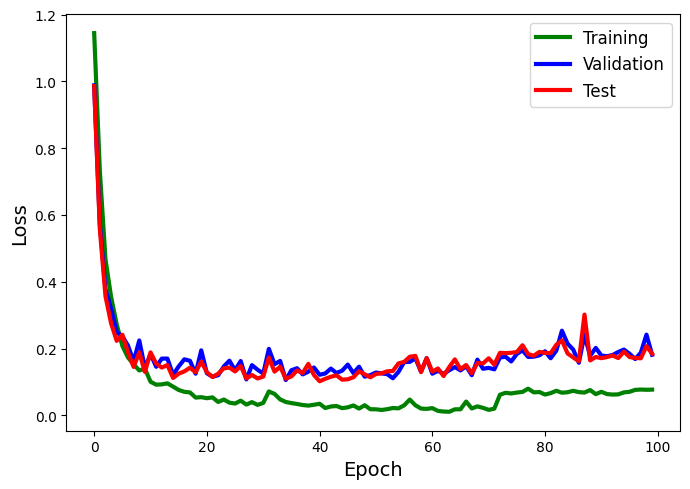

In [57]:
ensemble_tra_loss = np.mean(
    [
        all_histories[m]["train_loss"]
        for m in model_names
    ],
    axis=0
)

ensemble_val_loss = np.mean(
    [
        all_histories[m]["val_loss"]
        for m in model_names
    ],
    axis=0
)
ensemble_test_loss = np.mean(
    [
        all_histories[m]["test_loss"]
        for m in model_names
    ],
    axis=0
)
plt.figure(figsize=(7,5))

plt.plot(
    ensemble_train_loss,
    color="green",
    linewidth=3,
    label="Training"
)

plt.plot(
    ensemble_val_loss,
    color="blue",
    linewidth=3,
    label="Validation"
)
plt.plot(
    ensemble_test_loss,
    color="red",
    linewidth=3,
    label="Test"
)
plt.xlabel(
    "Epoch",
    fontsize=14
)

plt.ylabel(
    "Loss",
    fontsize=14
)

plt.legend(
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "Ensemble_LossCurve.png",
    dpi=600
)

plt.show()